# Applying Dimensionality Reduction to Real-World Datasets (Images and Text)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply dimensionality reduction techniques to real-world image datasets
- Apply dimensionality reduction techniques to text data
- Compare PCA, SVD, and t-SNE on different data types
- Evaluate dimensionality reduction performance

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — real, messy tables; here the same realism meets image and text data.

**Used later in:** Course 07 (AIAT 121) — Unit 2, lesson 02 "Word Embeddings" — text turned into vectors, then projected down to be seen.

---

This notebook covers practical activities from **Course 03, Unit 4**:
- Writing code to apply dimensionality reduction techniques on real-world datasets including images and text data

---

## Introduction

**Dimensionality reduction** is crucial for handling high-dimensional real-world data. This notebook demonstrates applying PCA, SVD, and t-SNE to image and text datasets.


---

## 📌 Real case: the benchmark that classifies email headers instead of topics

The 20 Newsgroups corpus that this notebook loads has been a standard text benchmark since the mid-1990s,
and scikit-learn ships a warning with it that is worth reading before you trust any result built on it:
"It is easy for a classifier to overfit on particular things that appear in the 20 Newsgroups data, such as
newsgroup headers... their results would not generalize to other documents." The documentation demonstrates
it. A multinomial naive Bayes classifier on the full posts reaches an F-score of **0.882**. Strip the
headers, signature blocks and quoted text with `remove=('headers','footers','quotes')` and the same
classifier drops to **0.773**. The features it had been relying on include whether a `NNTP-Posting-Host:`
header appears, whether the sender's signature shows a university affiliation, and the names and e-mail
addresses of particular people who happened to post in 1993.

**Note what this notebook does**: it calls `fetch_20newsgroups(...)` **without** `remove=`. So some of the
structure you are about to see in the 2D text plot is topic — and some of it is 1993 email plumbing.

**What goes wrong without this.** Nothing visible. You get separated clusters, a good number, and a model
that collapses the moment it meets a document from outside that corpus and that decade. Every real dataset
has a version of this, and finding it is not a modelling task — it is a reading task.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: the full dimensionality-reduction toolkit (PCA, TruncatedSVD, t-SNE),
# TF-IDF text vectorization, and real datasets: digit images and 20 Newsgroups posts,
# with real 911 call descriptions held in reserve as an offline text fallback.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits, fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Dimensionality Reduction to Real-World Datasets")
print("=" * 60)

✅ Libraries imported!

Applying Dimensionality Reduction to Real-World Datasets


## Part 1: Dimensionality Reduction on Image Data


Part 1: Dimensionality Reduction on Image Data

Image dataset shape: (1797, 64)
Original dimension: 64 (8x8 pixels)
Number of samples: 1797

PCA reduced to: (1797, 2)
Variance explained: 0.2159

Applying t-SNE (this may take a minute)...


t-SNE reduced to: (1000, 2)


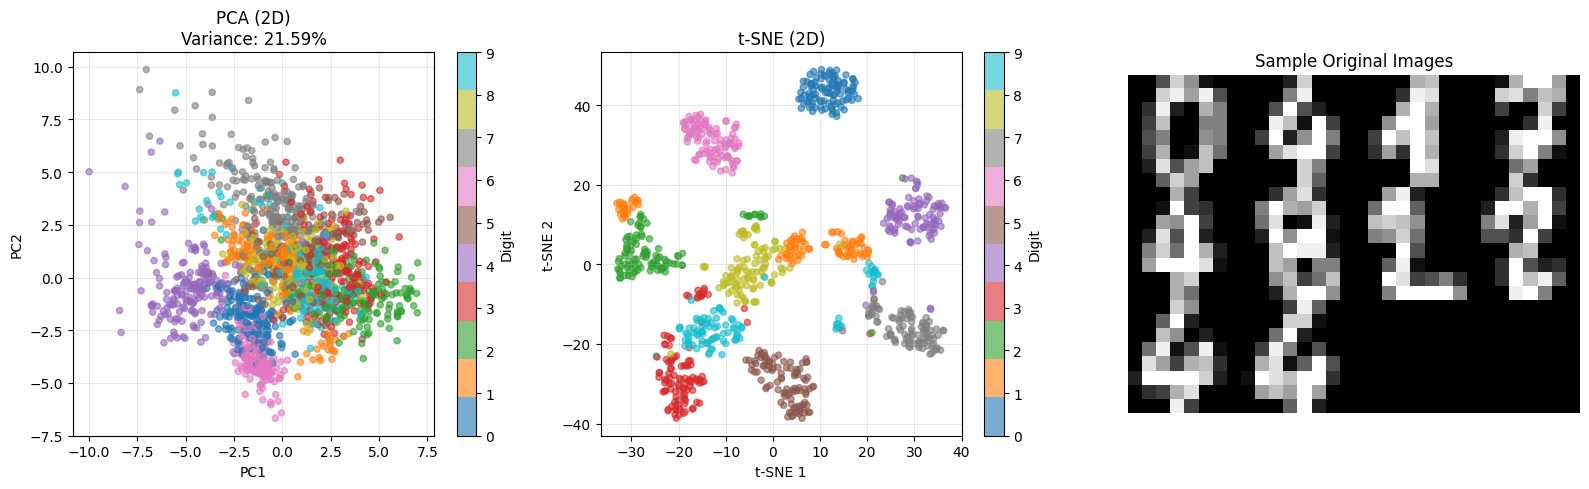


✅ Dimensionality reduction applied to image data!


In [2]:
# Real-world run #1 — images: standardize the 64-pixel digit vectors, then embed with PCA and t-SNE.
# The colored clusters answer a practical question: do raw pixels already separate the ten digits?

print("=" * 60)
print("Part 1: Dimensionality Reduction on Image Data")
print("=" * 60)

# Load digit images dataset
digits = load_digits()
X_images = digits.data
y_images = digits.target
images = digits.images

print(f"\nImage dataset shape: {X_images.shape}")
print(f"Original dimension: {X_images.shape[1]} (8x8 pixels)")
print(f"Number of samples: {X_images.shape[0]}")

# Standardize
scaler = StandardScaler()
X_images_scaled = scaler.fit_transform(X_images)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_images_scaled)
print(f"\nPCA reduced to: {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Apply t-SNE (takes longer)
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_images_scaled[:1000])  # Use subset for speed
print(f"t-SNE reduced to: {X_tsne.shape}")

# Visualize
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_images, cmap='tab10', alpha=0.6, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA (2D)\nVariance: {pca.explained_variance_ratio_.sum():.2%}')
plt.colorbar(scatter, label='Digit')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_images[:1000], cmap='tab10', alpha=0.6, s=20)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE (2D)')
plt.colorbar(scatter, label='Digit')
plt.grid(True, alpha=0.3)

# Show original images
plt.subplot(1, 3, 3)
sample_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
fig_grid = np.zeros((8*3, 8*4))
for i, idx in enumerate(sample_indices):
    row = (i // 4) * 8
    col = (i % 4) * 8
    fig_grid[row:row+8, col:col+8] = images[idx]
plt.imshow(fig_grid, cmap='gray')
plt.title('Sample Original Images')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Dimensionality reduction applied to image data!")

## Part 2: Dimensionality Reduction on Text Data



Part 2: Dimensionality Reduction on Text Data

Loading 20 Newsgroups dataset...


Loaded 500 text documents
Categories: {'sci.space', 'rec.autos', 'alt.atheism'}

Converting text to TF-IDF vectors...
TF-IDF matrix shape: (500, 1000)
High-dimensional text representation: 1000 features

SVD reduced to: (500, 2)
Variance explained: 0.0243
PCA reduced to: (500, 2)
Variance explained: 0.0378


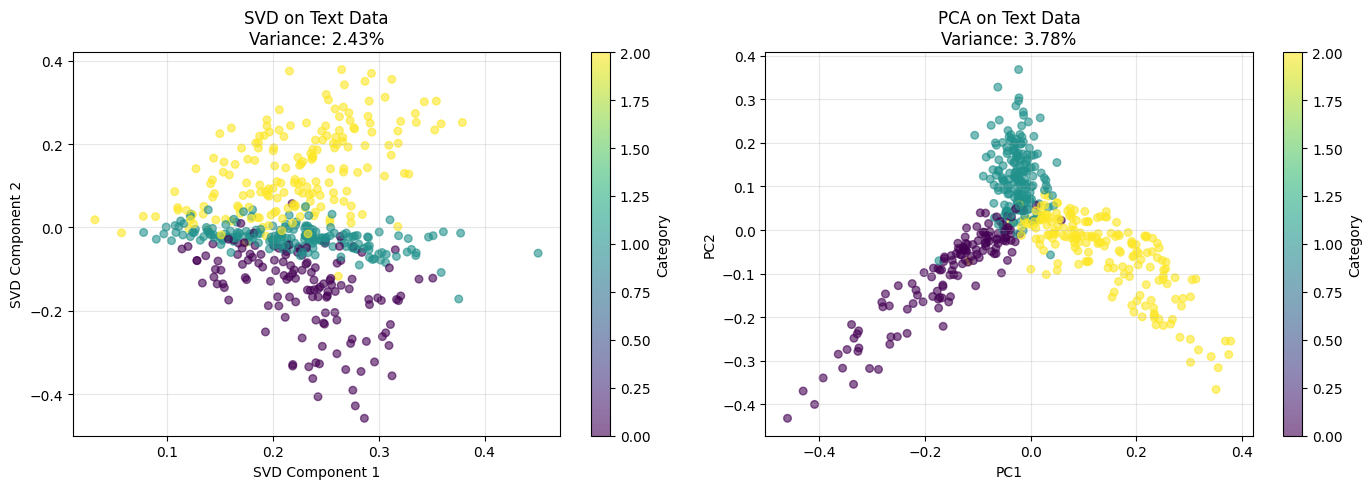


✅ Dimensionality reduction applied to text data!


In [3]:
# Real-world run #2 — text: TF-IDF turns 500 newsgroup posts into 1000-dim sparse vectors,
# then SVD (sparse-friendly) and PCA compress them to 2D. Topic clusters emerge without labels.

print("\n" + "=" * 60)
print("Part 2: Dimensionality Reduction on Text Data")
print("=" * 60)

# Load text dataset
print("\nLoading 20 Newsgroups dataset...")
try:
    newsgroups = fetch_20newsgroups(subset='train', categories=['alt.atheism', 'sci.space', 'rec.autos'], 
                                    shuffle=True, random_state=42)
    texts = newsgroups.data[:500]  # Use subset
    labels = newsgroups.target[:500]
    category_names = [newsgroups.target_names[i] for i in labels]
    print(f"Loaded {len(texts)} text documents")
    print(f"Categories: {set(category_names)}")
except Exception as err:
    # Fall back to REAL text held locally, never to invented sentences: the free-text
    # descriptions attached to Montgomery County 911 calls, labelled by call category.
    print(f"20 Newsgroups unavailable ({type(err).__name__}); using real 911 call descriptions instead.")
    calls = pd.read_csv(data_path("montgomery_911_calls.csv"),
                        usecols=["title", "desc"], nrows=20000)
    calls["category"] = calls["title"].str.split(":").str[0]
    calls = calls[calls["category"].isin(["EMS", "Fire", "Traffic"])]
    calls = calls.sample(n=500, random_state=42)
    texts = calls["desc"].astype(str).tolist()
    category_names = calls["category"].tolist()
    codes, uniques = pd.factorize(calls["category"])
    labels = np.asarray(codes)
    print(f"Loaded {len(texts)} real 911 call descriptions")
    print(f"Categories: {set(category_names)}")

# Convert text to TF-IDF vectors
print("\nConverting text to TF-IDF vectors...")
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.95, min_df=2)
X_text = vectorizer.fit_transform(texts)
print(f"TF-IDF matrix shape: {X_text.shape}")
print(f"High-dimensional text representation: {X_text.shape[1]} features")

# Apply SVD (works with sparse matrices)
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_text)
print(f"\nSVD reduced to: {X_svd.shape}")
print(f"Variance explained: {svd.explained_variance_ratio_.sum():.4f}")

# Apply PCA (needs dense matrix, so use SVD first for efficiency)
pca_text = PCA(n_components=2)
X_text_dense = X_text.toarray()  # Convert to dense (may be memory intensive)
X_pca_text = pca_text.fit_transform(X_text_dense)
print(f"PCA reduced to: {X_pca_text.shape}")
print(f"Variance explained: {pca_text.explained_variance_ratio_.sum():.4f}")

# Visualize
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_svd[:, 0], X_svd[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title(f'SVD on Text Data\nVariance: {svd.explained_variance_ratio_.sum():.2%}')
plt.colorbar(scatter, label='Category')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca_text[:, 0], X_pca_text[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA on Text Data\nVariance: {pca_text.explained_variance_ratio_.sum():.2%}')
plt.colorbar(scatter, label='Category')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Dimensionality reduction applied to text data!")

---

## ⚠️ Where this breaks

- **"Variance explained" is almost meaningless for sparse text, and the printout shows it.** SVD to 2
  components explains **2.43%** of the variance of the TF-IDF matrix; PCA explains **3.78%**. Yet the plot
  shows visible topic structure. Both facts are true: with 1,000 sparse term dimensions the variance is
  spread almost evenly, so the ratio is a bad summary of whether the projection is useful. Judge a text
  embedding by a downstream task, not by explained variance.
- **The clusters may be partly an artefact of the corpus.** As above: headers, signatures and quoted
  replies were left in. Before drawing any conclusion about "topics separating", re-run with
  `remove=('headers','footers','quotes')` and see how much of the structure survives. That is a
  five-character change and it is the most informative experiment in this notebook.
- **The two runs are not comparable, and should not be compared.** Part 1 standardizes 64 dense pixel
  features; Part 2 uses 1,000 sparse TF-IDF features and deliberately does *not* centre them, because
  centring a sparse matrix destroys the sparsity that made it affordable. That is why `TruncatedSVD` exists
  alongside `PCA`. Any statement of the form "PCA did better on images than on text" is comparing two
  different procedures on two different data types with two different preprocessing steps.
- **t-SNE was run on 1,000 of the 1,797 images for speed.** The subset is not random with respect to
  anything in particular, but it is a subset, and the embedding would look different for another one.


---

## 💬 Discuss

1. Removing headers and quotes costs the benchmark classifier 11 F-score points. Is the higher number
   *wrong*, or is it correct for a question nobody wanted answered? What does that distinction mean for
   how you read leaderboards?
2. Two components explain 2.4% of the variance in the text data and the plot still shows structure. What
   does that tell you about using explained variance to choose the number of components for sparse data —
   and what would you use instead?
3. You are asked to build a topic clustering for Arabic customer-support tickets from a Saudi telecom.
   Name three "header-like" leaks that could appear in that data — things that separate the classes for
   reasons that have nothing to do with the topic — and say how you would detect each one.


## Summary

### Key Concepts:
1. **Image Data**: High-dimensional pixel vectors, benefit from PCA/t-SNE
2. **Text Data**: High-dimensional TF-IDF vectors, benefit from SVD/PCA
3. **PCA**: Linear, preserves global structure, works on dense matrices
4. **SVD**: Linear, works on sparse matrices (good for text)
5. **t-SNE**: Non-linear, preserves local structure, good for visualization

### Best Practices:
- Standardize data before PCA
- Use SVD for sparse matrices (text data)
- Use t-SNE for visualization (may be slow)
- Consider variance explained when selecting components
- Evaluate based on downstream task performance

### Applications:
- Image compression and visualization
- Text document clustering
- Feature extraction for ML models
- Data exploration and visualization

**Reference:** Course 03, Unit 4: "Dimensionality Reduction" - Real-world datasets practical content

## 📚 References

1. Hotelling, H. (1933). *Analysis of a Complex of Statistical Variables into Principal Components*. Journal of Educational Psychology, 24, 417–441.
2. van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. <https://jmlr.org/papers/v9/vandermaaten08a.html>
3. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv. <https://arxiv.org/abs/1802.03426>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 12: Unsupervised Learning. Springer. <https://www.statlearning.com/>